# 2. Individual Table Cleaning

#### Important:
- one case (patient) can have multiple reports (recurring) - but in demo as checked in Scope section already one case = one report only
- primary key = unique per report, caseid = unique cases
- one case can have many reports


| Table      | What it contains                    | Key column  |
| ---------- | ----------------------------------- | ----------- |
| demo     | Patient demographics                | primaryid |
| drug     | Drug info (role, name, indication)  | primaryid |
| reaction | Adverse reactions (PT terms)        | primaryid |
| outcome  | Patient outcomes (DE, HO, LT, etc.) | primaryid |




only demo table is suppose to have unique PK (indicates one report per row, foreign key caseid = indicate possible followups on same case)

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load Data

In [10]:
# demo_table = pd.read_csv("/kaggle/input/datasets/alyssandra14/2025-data/2025_data/demo_2025.csv", sep=',', low_memory=False, index_col=0)
# drug_table = pd.read_csv("/kaggle/input/datasets/alyssandra14/2025-data/2025_data/drug_2025.csv", sep=',', low_memory=False, index_col=0, dtype={'nda_num': str})
# reaction_table = pd.read_csv("/kaggle/input/datasets/alyssandra14/2025-data/2025_data/reaction_2025.csv", sep=',', low_memory=False, index_col=0)
# outcome_table = pd.read_csv("/kaggle/input/datasets/alyssandra14/2025-data/2025_data/outcome_2025.csv", sep=',', low_memory=False, index_col=0)

In [11]:
demo_table = pd.read_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/2025_data/outputs/demo_2025.csv", sep=',', low_memory=False, index_col=0)
drug_table = pd.read_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/2025_data/outputs/drug_2025.csv", sep=',', low_memory=False, index_col=0, dtype={'nda_num': str})
reaction_table = pd.read_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/2025_data/outputs/reaction_2025.csv", sep=',', low_memory=False, index_col=0)
outcome_table = pd.read_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/2025_data/outputs/outcome_2025.csv", sep=',', low_memory=False, index_col=0)

#### Clean 1: Removing duplicates

In [12]:
drug_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7801018 entries, 0 to 7801017
Data columns (total 20 columns):
 #   Column         Dtype  
---  ------         -----  
 0   primaryid      int64  
 1   caseid         int64  
 2   drug_seq       int64  
 3   role_cod       object 
 4   drugname       object 
 5   prod_ai        object 
 6   val_vbm        int64  
 7   route          object 
 8   dose_vbm       object 
 9   cum_dose_chr   float64
 10  cum_dose_unit  object 
 11  dechal         object 
 12  rechal         object 
 13  lot_num        object 
 14  exp_dt         float64
 15  nda_num        object 
 16  dose_amt       float64
 17  dose_unit      object 
 18  dose_form      object 
 19  dose_freq      object 
dtypes: float64(3), int64(4), object(13)
memory usage: 1.2+ GB


In [13]:
# check for raw demo table
demo_table.duplicated().value_counts()

False    1617313
True         131
Name: count, dtype: int64

In [14]:
# removing duplicates in demo table
print("Before:", len(demo_table))
processed_demo = demo_table.drop_duplicates()
print("After:", len(processed_demo))
print("Duplicate rows removed:", len(demo_table) - len(processed_demo))


Before: 1617444
After: 1617313
Duplicate rows removed: 131


In [15]:
# sanity check for demo table
processed_demo.duplicated().value_counts()

False    1617313
Name: count, dtype: int64

In [16]:
# drug table
# allows same primary id and case id but remove exact row duplicates
drug_table.duplicated().value_counts()

False    7798481
True        2537
Name: count, dtype: int64

In [17]:
# removing duplicates in drug table
print("Before:", len(drug_table))
processed_drug = drug_table.drop_duplicates()
print("After:", len(processed_drug))
print("Duplicate rows removed:", len(drug_table) - len(processed_drug))

Before: 7801018
After: 7798481
Duplicate rows removed: 2537


In [18]:
# sanity check for drug table
processed_drug.duplicated().value_counts()

False    7798481
Name: count, dtype: int64

In [19]:
# reaction table
# allows same primary id and case id but remove exact row duplicates
reaction_table.duplicated().value_counts()

False    5587336
True       70494
Name: count, dtype: int64

In [20]:
# removing duplicates in reaction table
print("Before:", len(reaction_table))
processed_reaction = reaction_table.drop_duplicates()
print("After:", len(processed_reaction))
print("Duplicate rows removed:", len(reaction_table) - len(processed_reaction))

Before: 5657830
After: 5587336
Duplicate rows removed: 70494


In [21]:
# sanity check for reaction table
processed_reaction.duplicated().value_counts()

False    5587336
Name: count, dtype: int64

In [22]:
# outcome table
# allows same primary id and case id but remove exact row duplicates
outcome_table.duplicated().value_counts()

False    1232458
True         124
Name: count, dtype: int64

In [23]:
# removing duplicates in outcome table
print("Before:", len(outcome_table))
processed_outcome = outcome_table.drop_duplicates()
print("After:", len(processed_outcome))
print("Duplicate rows removed:", len(outcome_table) - len(processed_outcome))

Before: 1232582
After: 1232458
Duplicate rows removed: 124


In [24]:
# sanity check for outcome table
processed_outcome.duplicated().value_counts()

False    1232458
Name: count, dtype: int64

#### Clean 2: Drop Cols that have mssing values > 50 %

In [25]:
missing_percent_demo = processed_demo.isna().mean() * 100
missing_percent_drug = processed_drug.isna().mean() * 100
missing_percent_react = processed_reaction.isna().mean() * 100
missing_percent_outc = processed_outcome.isna().mean() * 100
print(missing_percent_demo, "\n")
print(missing_percent_drug, "\n")
print(missing_percent_react, "\n")
print(missing_percent_outc, "\n")

primaryid            0.000000
caseid               0.000000
caseversion          0.000000
i_f_code             0.000000
event_dt            56.268391
mfr_dt               0.000000
init_fda_dt          0.000000
fda_dt               0.000000
rept_cod             0.000000
auth_num            90.765053
mfr_num              3.361625
mfr_sndr             0.000000
lit_ref             90.855697
age                 39.687865
age_cod             39.683908
age_grp             63.981493
sex                 19.779288
e_sub                0.000000
wt                  83.084227
wt_cod              83.084289
rept_dt              0.000000
to_mfr              96.816510
occp_cod            13.874865
reporter_country     0.000124
occr_country         4.919456
dtype: float64 

primaryid         0.000000
caseid            0.000000
drug_seq          0.000000
role_cod          0.000000
drugname          0.000000
prod_ai           1.714129
val_vbm           0.000000
route            36.182777
dose_vbm         

In [26]:
# See columns with >50% missing
demo_cols_drop = missing_percent_demo[missing_percent_demo > 50].index
drug_cols_drop = missing_percent_drug[missing_percent_drug > 50].index
react_cols_drop = missing_percent_react[missing_percent_react > 50].index
outc_cols_drop = missing_percent_outc[missing_percent_outc > 50].index

processed_demo = processed_demo.drop(columns=demo_cols_drop)
processed_drug = processed_drug.drop(columns=drug_cols_drop)
processed_reaction = processed_reaction.drop(columns=react_cols_drop)
processed_outcome = processed_outcome.drop(columns=outc_cols_drop)

In [27]:
processed_demo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1617313 entries, 0 to 1617443
Data columns (total 18 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   primaryid         1617313 non-null  int64  
 1   caseid            1617313 non-null  int64  
 2   caseversion       1617313 non-null  int64  
 3   i_f_code          1617313 non-null  object 
 4   mfr_dt            1617313 non-null  int64  
 5   init_fda_dt       1617313 non-null  int64  
 6   fda_dt            1617313 non-null  int64  
 7   rept_cod          1617313 non-null  object 
 8   mfr_num           1562945 non-null  object 
 9   mfr_sndr          1617313 non-null  object 
 10  age               975436 non-null   float64
 11  age_cod           975500 non-null   object 
 12  sex               1297420 non-null  object 
 13  e_sub             1617313 non-null  object 
 14  rept_dt           1617313 non-null  int64  
 15  occp_cod          1392913 non-null  object 
 16  repor

In [28]:
processed_drug.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7798481 entries, 0 to 7801017
Data columns (total 10 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   primaryid  int64 
 1   caseid     int64 
 2   drug_seq   int64 
 3   role_cod   object
 4   drugname   object
 5   prod_ai    object
 6   val_vbm    int64 
 7   route      object
 8   dose_vbm   object
 9   dechal     object
dtypes: int64(4), object(6)
memory usage: 654.5+ MB


In [29]:
processed_reaction.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5587336 entries, 0 to 5657829
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   primaryid  int64 
 1   caseid     int64 
 2   pt         object
dtypes: int64(2), object(1)
memory usage: 170.5+ MB


In [30]:
processed_outcome.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1232458 entries, 0 to 1232581
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   primaryid  1232458 non-null  int64 
 1   caseid     1232458 non-null  int64 
 2   outc_cod   1232458 non-null  object
dtypes: int64(2), object(1)
memory usage: 37.6+ MB


#### Clean 3: Fix Inconsistent Formats: String, Data Type Conversion & Unit Transformation

##### 1. Demo Table

In [31]:
# DEMO TABLE
# check categorical data
# skip primaryid, caseid, caseversion
processed_demo['i_f_code'].value_counts() # consistent


i_f_code
I    1082510
F     534803
Name: count, dtype: int64

In [32]:
processed_demo['rept_cod'].value_counts() # consistent

rept_cod
EXP      855340
PER      674425
DIR       54369
30DAY     32110
5DAY       1069
Name: count, dtype: int64

In [33]:
processed_demo['mfr_num'].value_counts()

mfr_num
US-SHIRE-US202014913                                    4
US-SHIRE-US202020949                                    4
CA-JNJFOC-20240542251                                   4
US-SHIRE-US202030031                                    4
CA-JNJFOC-20230106897                                   4
                                                       ..
CA-009507513-1406CAN004402                              1
US-AMGEN-USASP2013081332                                1
US-Blueprint Medicines Corporation-SP-US-2024-000717    1
US-ROCHE-1428166                                        1
AUR-APL-2014-02441                                      1
Name: count, Length: 1422226, dtype: int64

In [34]:
# change all to upper (Astrazeneca) is small letters
processed_demo['mfr_num_clean'] = (processed_demo['mfr_num'].str.strip().str.upper())

In [35]:
processed_demo['mfr_num_clean'].value_counts()

mfr_num_clean
GB-IPSEN BIOPHARMACEUTICALS, INC.-2023-16536    4
US-SHIRE-US202034452                            4
US-SHIRE-US202021429                            4
CA-TAKEDA-2022TUS012911                         4
JP-ASTRAZENECA-202412GLO015920JP                4
                                               ..
US-ROCHE-1428166                                1
IT-UCBSA-2014006004                             1
PHHY2014IN087849                                1
CA-ROCHE-1443486                                1
JP-UCBSA-2025069269                             1
Name: count, Length: 1422213, dtype: int64

In [36]:
processed_demo['mfr_sndr'].value_counts()

mfr_sndr
SANOFI AVENTIS                      169281
ABBVIE                               89975
ELI LILLY AND COMPANY                82995
ALEXION PHARMACEUTICALS              81372
PFIZER                               75965
                                     ...  
Mitem Pharma                             1
SANKALP LIFECARE INC.                    1
LIVZON PHARMA                            1
LFB GROUP                                1
CARWIN PHARMACEUTICAL ASSOCIATES         1
Name: count, Length: 920, dtype: int64

In [37]:
# 1. Initial Standardizing (Case & Whitespace)
processed_demo['mfr_sndr_clean'] = (
    processed_demo['mfr_sndr']
    .str.upper()
    .str.strip()
)

# 2. Remove Specific Metadata & Location Tags
# This handles your '- NO LOCATION SPECIFIED' and similar patterns
remove_patterns = [
    r' - NO LOCATION SPECIFIED',
    r'\(.*\)',              # Remove anything in parentheses
    r'DBA\b.*'              # Remove "Doing Business As" and everything after it
]
for pattern in remove_patterns:
    processed_demo['mfr_sndr_clean'] = processed_demo['mfr_sndr_clean'].str.replace(pattern, '', regex=True)

# 3. Strip Legal Suffixes (Inc, LLC, etc.)
# We use word boundaries (\b) so we don't accidentally strip "LTD" out of "ALTDORFER"
suffixes = r'\b(INC|LLC|CORP|CORPORATION|LTD|LIMITED|PLC|GROUP|CO|COMPANY|SA|AG)\b'
processed_demo['mfr_sndr_clean'] = (
    processed_demo['mfr_sndr_clean']
    .str.replace(suffixes, '', regex=True)
)

# 4. Remove Punctuation & Special Characters
# Keeps only letters, numbers, and spaces
processed_demo['mfr_sndr_clean'] = (
    processed_demo['mfr_sndr_clean']
    .str.replace(r'[^A-Z0-9\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True) # Collapse multiple spaces into one
    .str.strip()
)

# 5. Final Nullification
# Handles "UNKNOWN", "NOT AVAILABLE", "N/A", or empty strings
null_patterns = r'.*UNKNOWN.*|.*NOT AVAILABLE.*|^N/A$|^$'
processed_demo['mfr_sndr_clean'] = (
    processed_demo['mfr_sndr_clean']
    .replace(null_patterns, np.nan, regex=True)
)

In [38]:
processed_demo['mfr_sndr_clean'].value_counts()

mfr_sndr_clean
SANOFI AVENTIS                     169281
ABBVIE                              89975
ELI LILLY AND                       87186
ALEXION PHARMACEUTICALS             81372
PFIZER                              75965
                                    ...  
DUTCH OPTHALMIC RESEARCH CENTER         1
LFB                                     1
SANKALP LIFECARE                        1
EXTROVIS                                1
CRINETICS PHARMACEUTICALS               1
Name: count, Length: 842, dtype: int64

In [39]:
print(processed_demo['mfr_sndr'].isna().sum())
print(processed_demo['mfr_sndr_clean'].isna().sum())

0
2159


Missing values for mfr_sndr went from 0 to 755

In [40]:
print(processed_demo['mfr_sndr_clean'].isna().mean() * 100)

0.13349302206808453


In [41]:
# age_cod
processed_demo['age_cod'].value_counts() # consistent


age_cod
YR     954310
DEC     15029
MON      4493
DY       1105
WK        513
HR         50
Name: count, dtype: int64

In [42]:
# sex
processed_demo['sex'].value_counts() # change unk to na

sex
F      775986
M      520398
UNK      1036
Name: count, dtype: int64

In [43]:
# replace UNK with NaN
processed_demo['sex_clean'] = processed_demo['sex'].replace("UNK", np.nan)


In [44]:
print(processed_demo['sex'].isna().sum())
print(processed_demo['sex_clean'].isna().sum())

319893
320929


Missing values increased for sex

In [45]:
print(processed_demo['sex_clean'].isna().mean() * 100)

19.84334510388527


In [46]:
# e_sub - this report was submitted under the electronic submissions procedure for manufacturers
processed_demo['e_sub'].value_counts() # consistent

e_sub
Y    1562939
N      54374
Name: count, dtype: int64

In [47]:
# occp_cod
processed_demo['occp_cod'].value_counts() # consistent

occp_cod
CN    611904
HP    360302
MD    329750
PH     80646
LW     10311
Name: count, dtype: int64

In [48]:
#reporter_country
processed_demo['reporter_country'].value_counts() # results show consistent

reporter_country
US    1061721
CA     105378
EU      90353
JP      65887
GB      60465
       ...   
XK          1
TM          1
AW          1
JE          1
CV          1
Name: count, Length: 194, dtype: int64

In [49]:
# replace 'COUNTRY NOT SPECIFIED' with NaN
processed_demo['reporter_country_clean'] = processed_demo['reporter_country'].replace("COUNTRY NOT SPECIFIED", np.nan)

In [50]:
print(processed_demo['reporter_country'].isna().sum())
print(processed_demo['reporter_country_clean'].isna().sum())

2
2465


Missing value increased by 513 for reporter country

In [51]:
print(processed_demo['reporter_country_clean'].isna().mean() * 100)

0.15241329291237998


In [52]:
#occr_country
processed_demo['occr_country'].value_counts() # results show consistent

occr_country
US    988897
CA    103811
EU     89419
JP     65792
GB     59816
       ...  
XK         1
TM         1
AW         1
FJ         1
JE         1
Name: count, Length: 196, dtype: int64

In [53]:
# check numerical data
# change to date format
processed_demo['mfr_dt'] = pd.to_datetime(processed_demo['mfr_dt'], format='%Y%m%d', errors='coerce')
processed_demo['init_fda_dt'] = pd.to_datetime(processed_demo['init_fda_dt'], format='%Y%m%d', errors='coerce')
processed_demo['fda_dt'] = pd.to_datetime(processed_demo['fda_dt'], format='%Y%m%d', errors='coerce')
processed_demo['rept_dt'] = pd.to_datetime(processed_demo['rept_dt'], format='%Y%m%d', errors='coerce')

In [54]:
processed_demo['mfr_dt']

0         2025-03-19
1         2014-03-24
2         2014-04-14
3         2025-01-06
4         2025-01-29
             ...    
1617439   2025-11-05
1617440   2025-11-14
1617441   2025-10-24
1617442   2025-10-30
1617443   2025-11-17
Name: mfr_dt, Length: 1617313, dtype: datetime64[ns]

In [55]:
processed_demo['init_fda_dt']

0         2014-03-22
1         2014-04-01
2         2014-04-02
3         2014-04-04
4         2014-04-09
             ...    
1617439   2014-01-28
1617440   2014-02-05
1617441   2014-02-07
1617442   2014-03-11
1617443   2014-03-06
Name: init_fda_dt, Length: 1617313, dtype: datetime64[ns]

In [56]:
processed_demo['fda_dt']

0         2025-03-26
1         2025-03-07
2         2025-02-27
3         2025-01-10
4         2025-02-03
             ...    
1617439   2025-11-11
1617440   2025-11-21
1617441   2025-10-31
1617442   2025-11-07
1617443   2025-11-29
Name: fda_dt, Length: 1617313, dtype: datetime64[ns]

In [57]:
processed_demo['rept_dt']

0         2025-03-26
1         2025-03-07
2         2025-02-26
3         2025-01-10
4         2025-02-03
             ...    
1617439   2025-11-11
1617440   2025-11-21
1617441   2025-10-31
1617442   2025-11-07
1617443   2025-11-28
Name: rept_dt, Length: 1617313, dtype: datetime64[ns]

In [58]:
# age
# age_cod above indicates the inconsistency in units (decade, year, month, week, day, hour)
age_unit_map = {
    'YR': 1,
    'DEC': 10,
    'MON': 1/12,
    'WK': 1/52,
    'DY': 1/365,
    'HR': 1/(365*24)
}

processed_demo['age_yrs'] = (
    processed_demo['age'] *
    processed_demo['age_cod'].map(age_unit_map)
)

# Floor decimals (round down)
# YR and DECADE = no decimal = multiply whole numbers
# the rest divides = decimal means not yet full year
processed_demo['age_yrs'] = np.floor(processed_demo['age_yrs'])
processed_demo['age_yrs'] = np.floor(processed_demo['age_yrs']).astype('Int64')



In [59]:
processed_demo['age_yrs'].value_counts()

age_yrs
70     24326
60     22058
65     21505
68     20624
67     20372
       ...  
668        1
144        1
112        1
150        1
120        1
Name: count, Length: 132, dtype: Int64

##### 2. Drug Table

In [60]:
# skip primaryid, caseid, and drug_sequence
# check categorical values
processed_drug['role_cod'].value_counts() # DN - drug not administered

role_cod
SS    3092479
C     2885870
PS    1778060
I       41879
DN        193
Name: count, dtype: int64

In [61]:
processed_drug['role_cod'] = processed_drug['role_cod'].replace("DN", np.nan)
print(processed_drug['role_cod'].isna().sum())

193


In [62]:
processed_drug = processed_drug.dropna(subset=['role_cod'])
count_after = processed_drug['role_cod'].isna().sum()
print(count_after)

0


In [63]:
processed_drug['drugname'].value_counts()

drugname
DUPIXENT                     197028
MOUNJARO                     121974
ZEPBOUND                     112046
PREDNISONE                   107395
METHOTREXATE                  94361
                              ...  
FERROVIN                          1
Inaticabtagene autoleucel         1
TRIVISOL                          1
LEVOCETIRINE                      1
CHOLESTYRAMI RESIN                1
Name: count, Length: 73697, dtype: int64

In [64]:
processed_drug['drugname_clean'] = (
    processed_drug['drugname']
    .str.upper()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True) # make multispace into one space only
)


In [65]:
processed_drug['drugname_clean'].value_counts()


drugname_clean
DUPIXENT                                                   197028
MOUNJARO                                                   121974
ZEPBOUND                                                   112046
PREDNISONE                                                 107396
METHOTREXATE                                                94361
                                                            ...  
PRIMOBOLAN /00044802/                                           1
BISMUTH SUBCITRATE POTASSIUM\METRONIDAZOLE\TETRACYCLINE         1
CALCIUM+ D SOFT CHEWS CARAMEL                                   1
ITINOTECAN                                                      1
NUROFEN B?RNIEM SUSPENSIJA IEK???GAI LIETO?ANAI                 1
Name: count, Length: 66426, dtype: int64

In [66]:
processed_drug['prod_ai'].value_counts() # consistent

prod_ai
TIRZEPATIDE                                           236023
DUPILUMAB                                             199836
PREDNISONE                                            107843
INFLIXIMAB-DYYB                                        96094
METHOTREXATE                                           94461
                                                       ...  
FLUOXETINE\TADALAFIL                                       1
ONASEMNOGENE ABEPARVOVEC-BRVE                              1
CARRAGEENAN                                                1
GIBBERELLA FUJIKUROI\HAEMATONECTRIA HAEMATOCOCCA           1
MUCOR CIRCINELLOIDES F. LUSITANICUS\MUCOR PLUMBEUS         1
Name: count, Length: 8596, dtype: int64

In [67]:
unique_prodai = processed_drug['prod_ai'].dropna().unique()
unique_prodai = sorted(unique_prodai)

for ai in unique_prodai:
    print(ai)

.ALPHA.-ACETYLDIGOXIN
.ALPHA.-GLUCOSE-1-PHOSPHATE DISODIUM TETRAHYDRATE
.ALPHA.-HYDROXYALPRAZOLAM
.ALPHA.-LIPOIC ACID
.ALPHA.-PYRROLIDINOISOHEXANOPHENONE
.ALPHA.-PYRROLIDINOPENTIOPHENONE
.ALPHA.-PYRROLIDINOVALEROTHIOPHENONE
.ALPHA.-TOCOPHEROL
.ALPHA.-TOCOPHEROL ACETATE
.ALPHA.-TOCOPHEROL ACETATE, D-
.ALPHA.-TOCOPHEROL ACETATE, D-\ASCORBIC ACID\CHOLECALCIFEROL\CYANOCOBALAMIN\DOCONEXENT\FOLIC ACID\ICOSAPENT\IRON PENTACARBONYL\LEVOMEFOLATE MAGNESIUM\MAGNESIUM OXIDE\NIACIN\POTASSIUM IODIDE\PYRIDOXINE HYDROCHLORIDE\RIBOFLAVIN\THIAMINE HYDROCHLORIDE
.ALPHA.-TOCOPHEROL ACETATE, D-\EVENING PRIMROSE OIL\FISH OIL
.ALPHA.-TOCOPHEROL ACETATE, DL-
.ALPHA.-TOCOPHEROL ACETATE, DL-\.BETA.-CAROTENE\ASCORBIC ACID\CALCIUM CARBONATE\CALCIUM PANTOTHENATE\CHOLECALCIFEROL\CYANOCOBALAMIN\DOCUSATE SODIUM\FERROUS FUMARATE\FOLIC ACID\NIACINAMIDE\PYRIDOXINE HYDROCHLORIDE\RIBOFLAVIN\THIAMINE MONONITRATE\ZINC OXIDE
.ALPHA.-TOCOPHEROL ACETATE, DL-\.BETA.-CAROTENE\ASCORBIC ACID\CALCIUM CARBONATE\CHOLECALCIFEROL\CUPRI

In [68]:
## Too many values so check standardization 
original_unique = processed_drug['prod_ai'].nunique()

cleaned_unique = (
    processed_drug['prod_ai']
    .dropna()
    .str.strip()
    .str.upper()
    .nunique()
)

original_unique, cleaned_unique

(8596, 8596)

In [69]:
processed_drug['route'].value_counts()

route
Unknown                                  2157620
Oral                                     1022619
Subcutaneous                              696332
Intravenous (not otherwise specified)     450194
Intravenous use                            91438
                                          ...   
Via G-tube                                     1
via NG-tube                                    1
G-tube                                         1
By mouth                                       1
Drop For Injection                             1
Name: count, Length: 162, dtype: int64

In [70]:
processed_drug['route_clean'] =  processed_drug['route'].str.strip().str.upper()

processed_drug['route_clean'] = processed_drug['route_clean'].replace("UNKNOWN", np.nan)


In [71]:
print(processed_drug['route'].isna().sum())
print(processed_drug['route_clean'].isna().sum())

2821576
4979196


Missing value of route increased

In [72]:
print(processed_drug['route_clean'].isna().mean() * 100)

63.84986037961152


In [73]:
processed_drug.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7798288 entries, 0 to 7801017
Data columns (total 12 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   primaryid       int64 
 1   caseid          int64 
 2   drug_seq        int64 
 3   role_cod        object
 4   drugname        object
 5   prod_ai         object
 6   val_vbm         int64 
 7   route           object
 8   dose_vbm        object
 9   dechal          object
 10  drugname_clean  object
 11  route_clean     object
dtypes: int64(4), object(8)
memory usage: 773.5+ MB


In [74]:
processed_drug['dose_vbm'].value_counts() # replace UNK as NA

dose_vbm
UNK                                1857645
300 mg, QOW                         105175
UNK UNK, unknown                     48233
300 milligram                        46763
2.5 mg, unknown                      44567
                                    ...   
4 dosage form (4 DF, UNK)                1
UNK (pulses of high dose)                1
Therapy start date: 04-Feb-2015          1
2 ea                                     1
120 mL, daily                            1
Name: count, Length: 671365, dtype: int64

In [75]:
processed_drug['dose_vbm_clean'] =  processed_drug['dose_vbm'].str.strip().str.upper()
processed_drug['dose_vbm_clean'] = processed_drug['dose_vbm_clean'].replace("UNK", np.nan)

In [76]:
processed_drug['dose_vbm_clean']

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
          ... 
7801013    NaN
7801014    NaN
7801015    NaN
7801016    NaN
7801017    NaN
Name: dose_vbm_clean, Length: 7798288, dtype: object

In [77]:
processed_drug['dechal'].value_counts() # consistent

dechal
U    2992651
D    1097490
Y     457753
N      95321
Name: count, dtype: int64

In [78]:
#check numerical value
#val_vbm
processed_drug['val_vbm'].value_counts() #consistent

val_vbm
1    7673103
2     125185
Name: count, dtype: int64

##### 3. Reaction Table

In [79]:
processed_reaction.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5587336 entries, 0 to 5657829
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   primaryid  int64 
 1   caseid     int64 
 2   pt         object
dtypes: int64(2), object(1)
memory usage: 170.5+ MB


In [80]:
# skip primaryid, caseid
# pt = preferred term
processed_reaction['pt'].value_counts() # already mapped to MedDRA according to FDA

pt
Off label use                                117757
Drug ineffective                              92631
Fatigue                                       72109
Product dose omission issue                   65492
Nausea                                        62531
                                              ...  
Ureterocele                                       1
Expiratory reserve volume abnormal                1
Hair transplant                                   1
Carnitine palmitoyltransferase deficiency         1
Faecal lactoferrin                                1
Name: count, Length: 16794, dtype: int64

In [81]:
processed_reaction['pt_clean'] =  processed_reaction['pt'].str.strip().str.upper()

processed_reaction['pt_clean'] = processed_reaction['pt_clean'].replace("NO ADVERSE EVENT", np.nan)

In [82]:
processed_reaction.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5587336 entries, 0 to 5657829
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   primaryid  int64 
 1   caseid     int64 
 2   pt         object
 3   pt_clean   object
dtypes: int64(2), object(2)
memory usage: 213.1+ MB


##### 4. OUTCOME TABLE

In [83]:
# skip primaryid, caseid 
processed_outcome['outc_cod'].value_counts() #consistent

outc_cod
OT    682814
HO    336960
DE    121416
LT     54295
DS     25918
CA      6079
RI      4976
Name: count, dtype: int64

#### Clean 4: Outlier Handling (Numerical)

##### 1. DEMO table

In [84]:
processed_demo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1617313 entries, 0 to 1617443
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   primaryid               1617313 non-null  int64         
 1   caseid                  1617313 non-null  int64         
 2   caseversion             1617313 non-null  int64         
 3   i_f_code                1617313 non-null  object        
 4   mfr_dt                  1617312 non-null  datetime64[ns]
 5   init_fda_dt             1617313 non-null  datetime64[ns]
 6   fda_dt                  1617313 non-null  datetime64[ns]
 7   rept_cod                1617313 non-null  object        
 8   mfr_num                 1562945 non-null  object        
 9   mfr_sndr                1617313 non-null  object        
 10  age                     975436 non-null   float64       
 11  age_cod                 975500 non-null   object        
 12  sex                

In [85]:
# Demo table
# date outliers
processed_demo['mfr_dt'].describe() #minimum is an outlier

count                          1617312
mean     2025-05-22 23:59:53.963317248
min                1994-12-06 00:00:00
25%                2025-03-05 00:00:00
50%                2025-06-05 00:00:00
75%                2025-09-11 00:00:00
max                2035-06-03 00:00:00
Name: mfr_dt, dtype: object

In [86]:
# introducing filter, remove manufacturing before 2020 and after 2025
processed_demo['mfr_dt_clean'] = processed_demo['mfr_dt'].where(
    (processed_demo['mfr_dt'] >= '2020-01-01') &
    (processed_demo['mfr_dt'] <= '2025-12-31')
)

In [87]:
processed_demo['mfr_dt_clean'].describe()

count                          1614709
mean     2025-05-29 00:39:21.044620544
min                2020-01-02 00:00:00
25%                2025-03-06 00:00:00
50%                2025-06-06 00:00:00
75%                2025-09-11 00:00:00
max                2025-12-31 00:00:00
Name: mfr_dt_clean, dtype: object

In [88]:
processed_demo['rept_dt'].describe()

count                          1617312
mean     2025-07-01 17:42:32.662195200
min                2000-02-15 00:00:00
25%                2025-04-01 00:00:00
50%                2025-07-03 00:00:00
75%                2025-09-26 00:00:00
max                2026-01-01 00:00:00
Name: rept_dt, dtype: object

In [89]:
# logic: rept -> init -> fda
processed_demo['rept_dt_clean'] = processed_demo['rept_dt'].where(processed_demo['rept_dt'] >= '2025-01-01')

In [90]:
processed_demo['rept_dt_clean'].describe()

count                          1616763
mean     2025-07-01 20:25:04.900347136
min                2025-01-01 00:00:00
25%                2025-04-01 00:00:00
50%                2025-07-03 00:00:00
75%                2025-09-26 00:00:00
max                2026-01-01 00:00:00
Name: rept_dt_clean, dtype: object

In [91]:
processed_demo['init_fda_dt'].describe()

count                          1617313
mean     2025-03-29 21:47:17.032287232
min                2001-11-13 00:00:00
25%                2025-02-18 00:00:00
50%                2025-05-27 00:00:00
75%                2025-09-05 00:00:00
max                2025-12-31 00:00:00
Name: init_fda_dt, dtype: object

In [92]:
# check if init is before report
processed_demo['init_fda_dt_clean'] = processed_demo['init_fda_dt'].where(
    processed_demo['init_fda_dt'] >= processed_demo['rept_dt_clean']
)

# check how many were set to NA
num_na = processed_demo['init_fda_dt_clean'].isna().sum()
print(f"Number of INIT_FDA_DT set to NA because it was before REPT_DT: {num_na}")

Number of INIT_FDA_DT set to NA because it was before REPT_DT: 565638


In [93]:
processed_demo['init_fda_dt_clean'].describe()

count                          1051675
mean     2025-07-01 14:49:15.753440768
min                2025-01-01 00:00:00
25%                2025-03-31 00:00:00
50%                2025-07-02 00:00:00
75%                2025-09-29 00:00:00
max                2025-12-31 00:00:00
Name: init_fda_dt_clean, dtype: object

In [94]:
processed_demo['fda_dt'].describe()

count                          1617313
mean     2025-07-01 23:49:21.554382336
min                2024-09-27 00:00:00
25%                2025-04-01 00:00:00
50%                2025-07-03 00:00:00
75%                2025-09-26 00:00:00
max                2025-12-31 00:00:00
Name: fda_dt, dtype: object

In [95]:
# Set FDA_DT to NaT if it is before INIT_FDA_DT (row-by-row)
processed_demo['fda_dt_clean'] = processed_demo['fda_dt'].where(
    processed_demo['fda_dt'] >= processed_demo['init_fda_dt_clean']
)

# check how many were set to NA
num_na = processed_demo['fda_dt_clean'].isna().sum()
print(f"Number of FDA_DT set to NA because it was before INIT_FDA_DT: {num_na}")

Number of FDA_DT set to NA because it was before INIT_FDA_DT: 565645


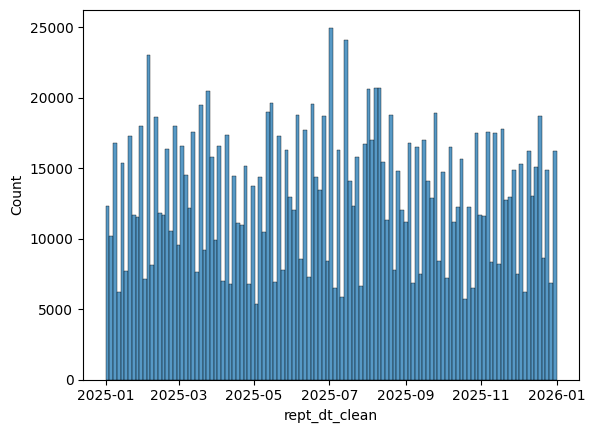

In [96]:
sns.histplot(data=processed_demo, x='rept_dt_clean')
plt.show()

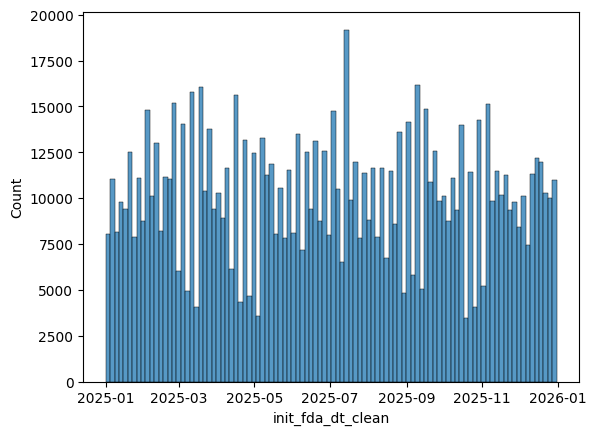

In [97]:
sns.histplot(data=processed_demo, x='init_fda_dt_clean')
plt.show()


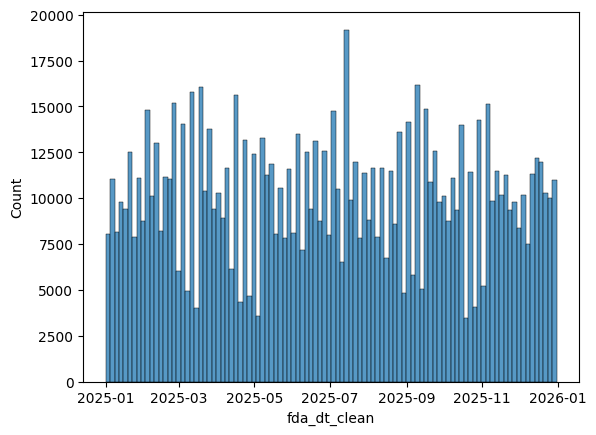

In [98]:
sns.histplot(data=processed_demo, x='fda_dt_clean')
plt.show()

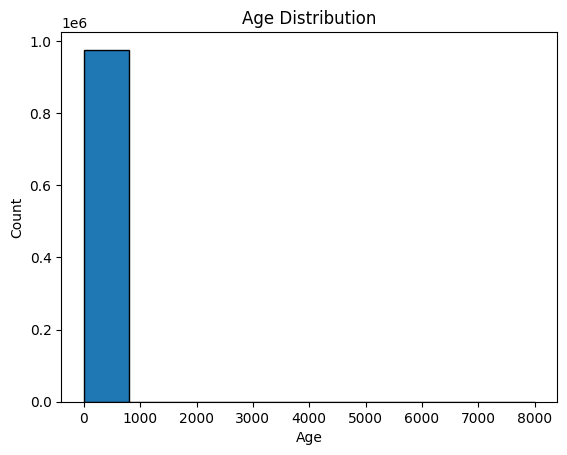

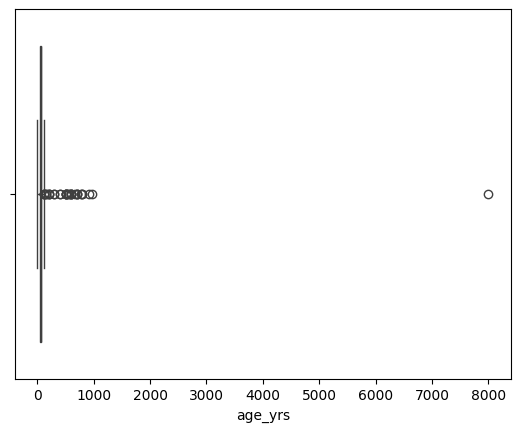

In [99]:
# check numerical values
# age_yrs

plt.hist(processed_demo['age_yrs'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

sns.boxplot(data = processed_demo, x='age_yrs')
plt.show()

In [100]:
# check describe
processed_demo['age_yrs'].describe() # outliers exist

count     975435.0
mean     54.632966
std      23.125811
min            0.0
25%           41.0
50%           59.0
75%           71.0
max         8000.0
Name: age_yrs, dtype: Float64

In [101]:
# Keep only realistic ages (0 - newborns)
processed_demo['age_yrs_clean'] = processed_demo['age_yrs'].where(processed_demo['age_yrs'].between(0, 100), np.nan)


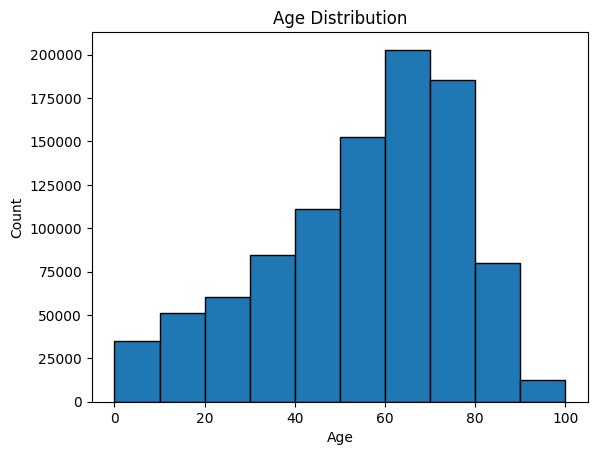

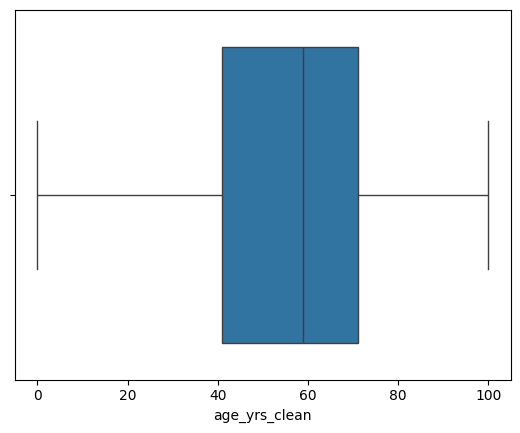

In [102]:
plt.hist(processed_demo['age_yrs_clean'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

sns.boxplot(data = processed_demo, x='age_yrs_clean')
plt.show()

#### Clean 5: Checking for NA percentage again (result - droped one col (NA > 50%) 

In [103]:
# cleaned, remove older cols
demo_new = processed_demo.drop(['mfr_num', 'mfr_sndr', 'sex', 'reporter_country', 'age', 'age_cod', 'age_yrs', 'mfr_dt', 'rept_dt', 'init_fda_dt', 'fda_dt'], axis=1)
drug_new = processed_drug.drop(['drugname', 'dose_vbm', 'route'], axis=1)
reaction_new = processed_reaction.drop('pt', axis=1)
outcome_new = processed_outcome

In [104]:
missing_percent_demo = demo_new.isna().mean() * 100
missing_percent_drug = drug_new.isna().mean() * 100
missing_percent_react = reaction_new.isna().mean() * 100
missing_percent_outc = outcome_new.isna().mean() * 100
print(missing_percent_demo, "\n")
print(missing_percent_drug, "\n")
print(missing_percent_react, "\n")
print(missing_percent_outc, "\n")

primaryid                  0.000000
caseid                     0.000000
caseversion                0.000000
i_f_code                   0.000000
rept_cod                   0.000000
e_sub                      0.000000
occp_cod                  13.874865
occr_country               4.919456
mfr_num_clean              3.361625
mfr_sndr_clean             0.133493
sex_clean                 19.843345
reporter_country_clean     0.152413
mfr_dt_clean               0.161008
rept_dt_clean              0.034007
init_fda_dt_clean         34.973935
fda_dt_clean              34.974368
age_yrs_clean             39.698314
dtype: float64 

primaryid          0.000000
caseid             0.000000
drug_seq           0.000000
role_cod           0.000000
prod_ai            1.714171
val_vbm            0.000000
dechal            40.458534
drugname_clean     0.000000
route_clean       63.849860
dose_vbm_clean    52.491137
dtype: float64 

primaryid    0.000000
caseid       0.000000
pt_clean     0.320761
dtype: f

In [105]:
# drop cols
drug_new = drug_new.drop(['dose_vbm_clean', 'route_clean'], axis=1)

In [107]:
missing_percent_demo = demo_new.isna().mean() * 100
missing_percent_drug = drug_new.isna().mean() * 100
missing_percent_react = reaction_new.isna().mean() * 100
missing_percent_outc = outcome_new.isna().mean() * 100
print(missing_percent_demo, "\n")
print(missing_percent_drug, "\n")
print(missing_percent_react, "\n")
print(missing_percent_outc, "\n")

primaryid                  0.000000
caseid                     0.000000
caseversion                0.000000
i_f_code                   0.000000
rept_cod                   0.000000
e_sub                      0.000000
occp_cod                  13.874865
occr_country               4.919456
mfr_num_clean              3.361625
mfr_sndr_clean             0.133493
sex_clean                 19.843345
reporter_country_clean     0.152413
mfr_dt_clean               0.161008
rept_dt_clean              0.034007
init_fda_dt_clean         34.973935
fda_dt_clean              34.974368
age_yrs_clean             39.698314
dtype: float64 

primaryid          0.000000
caseid             0.000000
drug_seq           0.000000
role_cod           0.000000
prod_ai            1.714171
val_vbm            0.000000
dechal            40.458534
drugname_clean     0.000000
dtype: float64 

primaryid    0.000000
caseid       0.000000
pt_clean     0.320761
dtype: float64 

primaryid    0.0
caseid       0.0
outc_cod     

#### Clean 6: Rule-Based (Domain)

##### 1. Drop irrelevant values in pt

In [108]:
pt_counts = reaction_new['pt_clean'].value_counts()
pt_counts

pt_clean
OFF LABEL USE                                117757
DRUG INEFFECTIVE                              92631
FATIGUE                                       72109
PRODUCT DOSE OMISSION ISSUE                   65492
NAUSEA                                        62531
                                              ...  
URETEROCELE                                       1
EXPIRATORY RESERVE VOLUME ABNORMAL                1
HAIR TRANSPLANT                                   1
MAGNETIC RESONANCE IMAGING HEART ABNORMAL         1
FAECAL LACTOFERRIN                                1
Name: count, Length: 16793, dtype: int64

In [109]:
exclude_pts = [
    'DRUG INEFFECTIVE', 
    'OFF LABEL USE', 
    'PRODUCT DOSE OMISSION ISSUE',
    'INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION', 
    'INCORRECT DOSE ADMINISTERED',
    'PRODUCT USE IN UNAPPROVED INDICATION', 
    'COVID-19', 
    'INFLUENZA', 
    'ILLNESS'
]

# filter unwanted pts
reaction_new = reaction_new[~reaction_new['pt_clean'].isin(exclude_pts)]


In [110]:
# Keywords indicating non-clinical terms
non_clinical_terms = [
    "PRODUCT",
    "DEVICE",
    "THERAP",
    "PRESCRIB",
    "ADMINISTER",
    "PACKAGING",
    "STORAGE",
    "DELIVERY",
    "COMPLAINT",
    "OMISSION",
    "ERROR",
    "HOSPITALISATION",
    "SURGERY",
    "HOSPICE",
    "PATIENT DISSATISFACTION",
    "INABILITY TO AFFORD"
]

reaction_new = reaction_new[~reaction_new['pt_clean'].isin(non_clinical_terms)]


In [111]:
pt_counts = reaction_new['pt_clean'].value_counts()
pt_counts

pt_clean
FATIGUE                                 72109
NAUSEA                                  62531
DEATH                                   60628
DIARRHOEA                               60624
HEADACHE                                49662
                                        ...  
MALIGNANT RENAL HYPERTENSION                1
CONJUNCTIVAL VASCULAR DISORDER              1
CIRCULATING TUMOUR DNA TEST POSITIVE        1
BENIGN BREAST LUMP REMOVAL                  1
ULTRASOUND PANCREAS ABNORMAL                1
Name: count, Length: 16781, dtype: int64

In [112]:
# Define grouping function for single terms
def group_terms_single(pt):
    if pd.isna(pt):
        return None
    
    # RASH grouping
    if "RASH" in pt:
        return "RASH"
    
    # Injection site grouping
    elif "INJECTION SITE" in pt:
        return "INJECTION_SITE_REACTION"
    
    # Infection grouping
    elif "INFECTION" in pt:
        return "INFECTION"
    
    # Psychiatric grouping
    elif any(word in pt for word in [
        "DEPRESSION", "ANXIETY", "SUICID", 
        "PSYCHOTIC", "AGITATION", "MOOD"
    ]):
        return "PSYCHIATRIC_EVENT"
    
    else:
        return pt

# Apply to Pandas DataFrame
reaction_new["pt_clean"] = reaction_new["pt_clean"].apply(group_terms_single)

In [113]:
pt_counts = reaction_new['pt_clean'].value_counts()
pt_counts

pt_clean
INFECTION                                                       120048
INJECTION_SITE_REACTION                                          97287
FATIGUE                                                          72109
PSYCHIATRIC_EVENT                                                66898
RASH                                                             65931
                                                                 ...  
TRANSITIONAL CELL CARCINOMA URETHRA                                  1
GANGLIONEUROBLASTOMA                                                 1
EXTRANODAL MARGINAL ZONE B-CELL LYMPHOMA (MALT TYPE) STAGE I         1
ENCEPHALOCUTANEOUS ANGIOMATOSIS                                      1
RADIATION DYSPHAGIA                                                  1
Name: count, Length: 16179, dtype: int64

##### 2. Remove rows with null prod_ai

In [114]:
count_before = drug_new['prod_ai'].isna().sum()
drug_new = drug_new.dropna(subset=['prod_ai'])
count_after = drug_new['prod_ai'].isna().sum()

print("NA count before drop:", count_before)
print("Na count after drop:", count_after)

NA count before drop: 133676
Na count after drop: 0


#### Clean 7: Scoping to project

##### 1. Top 10 drugs (prod_ai) and top 10 reactions (pt)

- decide to use prod_ai for more accurate data (distinct)
- drug table includes brand, generic and even ingredients (considered duplicates of multiple brand of the same drug)

In [115]:
top10_drugs = (
    drug_new['prod_ai']
    .value_counts()
    .nlargest(10)
    .index
    .tolist()
)

# Filter drug table
drug_top10 = drug_new[drug_new['prod_ai'].isin(top10_drugs)].copy()

print("Top 10 drugs:", top10_drugs)
print("Drug table rows after filter:", len(drug_top10))

Top 10 drugs: ['TIRZEPATIDE', 'DUPILUMAB', 'PREDNISONE', 'INFLIXIMAB-DYYB', 'METHOTREXATE', 'ACETAMINOPHEN', 'VEDOLIZUMAB', 'RITUXIMAB', 'TOCILIZUMAB', 'INFLIXIMAB']
Drug table rows after filter: 1135394


In [116]:
top10_reactions = (
    reaction_new['pt_clean']
    .value_counts()
    .nlargest(10)
    .index
    .tolist()
)

# Filter reaction table
reaction_top10 = reaction_new[reaction_new['pt_clean'].isin(top10_reactions)].copy()

print("Top 10 reactions:", top10_reactions)
print("Reaction table rows after filter:", len(reaction_top10))

Top 10 reactions: ['INFECTION', 'INJECTION_SITE_REACTION', 'FATIGUE', 'PSYCHIATRIC_EVENT', 'RASH', 'NAUSEA', 'DEATH', 'DIARRHOEA', 'HEADACHE', 'DYSPNOEA']
Reaction table rows after filter: 702179


##### 2. Deduplication of cases (check)

In [117]:
# Sort by caseversion descending so latest comes first
print("Demo table row count (before):", len(demo_new))
demo_new = demo_new.sort_values("caseversion", ascending=False)

# Keep only the first row per caseid (latest version)
# Keep latest report per case
latest_reports = demo_new.sort_values("caseversion", ascending=False)\
                   .drop_duplicates(subset="caseid", keep="first")

print("Demo table row count (after):", len(latest_reports))

Demo table row count (before): 1617313
Demo table row count (after): 1469305


#### Clean 8: Export 

In [118]:
# import os

# # Define the path for the new directory
# directory_path = "/kaggle/working/clean_data"

# # Create the directory
# os.makedirs(directory_path, exist_ok=True)

# print(f"Directory created at: {directory_path}")

In [123]:
demo_new.to_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_demo_2025.csv")

In [124]:
drug_top10.to_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_drug_top10.csv")

In [125]:
reaction_top10.to_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_reaction_top10.csv")

In [ ]:
outcome_new.to_csv("C:/Documents/VSCODE/Fixing IR Preprocessing/Data/new_individual_data/clean_outcome_2025.csv")